In [1]:
!pip install --upgrade biopython wordcloud transformers tf-keras

  Using cached transformers-5.2.0-py3-none-any.whl.metadata (32 kB)
Using cached transformers-5.2.0-py3-none-any.whl (10.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.3/596.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 54.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.41.2
    Uninstalling transformers-4.41.2:
      Successfully uninstalled transformers-4.41.2


In [2]:
!pip uninstall -y transformers
!pip install transformers==4.41.2 tf-keras

Found existing installation: transformers 5.2.0
Uninstalling transformers-5.2.0:
  Successfully uninstalled transformers-5.2.0
  Using cached transformers-4.41.2-py3-none-any.whl.metadata (43 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.41.2-py3-none-any.whl (9.1 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.6 MB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2


In [3]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, TFAutoModel
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from google.colab import drive

In [6]:
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/NLP_Project_Final'

SAVE_RS = os.path.join(BASE_DIR, 'Results')
os.makedirs(SAVE_RS, exist_ok=True)

MODEL_DIR = os.path.join(BASE_DIR, 'Model')
DATA_DIR = os.path.join(MODEL_DIR, 'SplitData')

WEIGHTS_DIR = os.path.join(MODEL_DIR, 'Weights')
os.makedirs(WEIGHTS_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_data.csv')).dropna()
val_df = pd.read_csv(os.path.join(DATA_DIR, 'val_data.csv')).dropna()

In [8]:
TOKENIZER_NAME = 'allenai/scibert_scivocab_uncased'
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [9]:
MAX_LEN = 311

def scibert_encode(texts):
    return tokenizer(
        texts.tolist(),
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

print(">>> [ENCODING] Transforming text to SciBERT tokens...")
X_train_encoded = scibert_encode(train_df['text'])
X_val_encoded = scibert_encode(val_df['text'])

>>> [ENCODING] Transforming text to SciBERT tokens...


In [10]:
def prepare_bert_dataset(encoded_data, labels, batch_size=16):
    ds = tf.data.Dataset.from_tensor_slices((
        {
            "input_ids": encoded_data["input_ids"],
            "attention_mask": encoded_data["attention_mask"]
        },
        labels.values
    ))
    return ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = prepare_bert_dataset(X_train_encoded, train_df['label'])
val_ds = prepare_bert_dataset(X_val_encoded, val_df['label'])

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 311)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 311)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   1099184   ['input_ids[0][0]',           
 )                           ngAndCrossAttentions(last_   64         'attention_mask[0][0]']      
                             hidden_state=(None, 311, 7                                       

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


1997/1997 [==============================] - 2917s 1s/step - loss: 0.0860 - accuracy: 0.9751 - val_loss: 0.0471 - val_accuracy: 0.9845
Epoch 2/5
1997/1997 [==============================] - ETA: 0s - loss: 0.0473 - accuracy: 0.9870
Epoch 2: val_accuracy improved from 0.98447 to 0.98472, saving model to /content/drive/MyDrive/NLP_Project_Final/Model/Weights/scibert_best_weights.weights.h5
1997/1997 [==============================] - 2887s 1s/step - loss: 0.0473 - accuracy: 0.9870 - val_loss: 0.0536 - val_accuracy: 0.9847
Epoch 3/5
1997/1997 [==============================] - ETA: 0s - loss: 0.0316 - accuracy: 0.9918
Epoch 3: val_accuracy improved from 0.98472 to 0.98672, saving model to /content/drive/MyDrive/NLP_Project_Final/Model/Weights/scibert_best_weights.weights.h5
1997/1997 [==============================] - 2885s 1s/step - loss: 0.0316 - accuracy: 0.9918 - val_loss: 0.0492 - val_accuracy: 0.9867


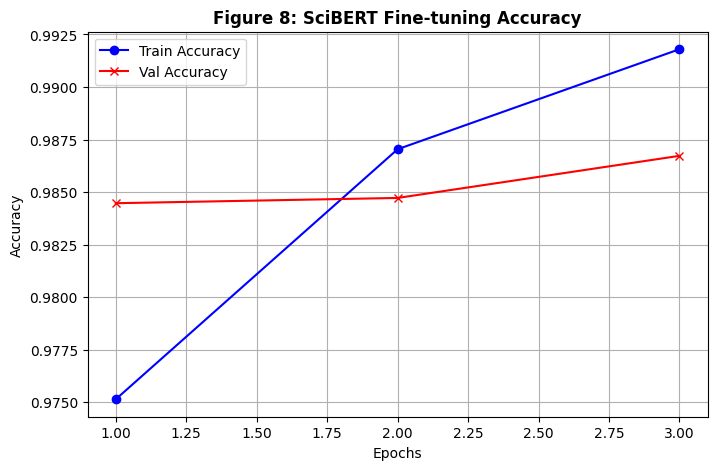


>>> [SUCCESS] SciBERT assets saved in: /content/drive/MyDrive/NLP_Project_Final/Model/Weights and /content/drive/MyDrive/NLP_Project_Final/Results


In [11]:
def build_scibert_model():
    input_ids = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
    attention_mask = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")

    scibert_base = TFAutoModel.from_pretrained(TOKENIZER_NAME, from_pt=True)

    embeddings = scibert_base(input_ids=input_ids, attention_mask=attention_mask).pooler_output

    x = tf.keras.layers.Dense(128, activation='relu')(embeddings)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

    model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=outputs)
    return model

model_scibert = build_scibert_model()
model_scibert.summary()

optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
model_scibert.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

ckpt_path = os.path.join(WEIGHTS_DIR, 'scibert_best_weights.weights.h5')
checkpoint = ModelCheckpoint(
    ckpt_path, monitor='val_accuracy', save_best_only=True,
    save_weights_only=True, mode='max', verbose=1
)
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("\n>>> [TRAINING] SciBERT Fine-tuning is starting...")
history = model_scibert.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)

def plot_scibert_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, acc, 'b-o', label='Train Accuracy')
    plt.plot(epochs, val_acc, 'r-x', label='Val Accuracy')
    plt.title('Figure 8: SciBERT Fine-tuning Accuracy', fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.savefig(os.path.join(SAVE_RS, 'scibert_learning_curves.png'), dpi=300)
    plt.show()

plot_scibert_curves(history)

model_scibert.save(os.path.join(WEIGHTS_DIR, 'scibert_last_full_model.keras'))
print(f"\n>>> [SUCCESS] SciBERT assets saved in: {WEIGHTS_DIR} and {SAVE_RS}")

In [13]:
import numpy as np

label_names = ['Case Report', 'Meta-Analysis', 'Observational Study', 'Randomized Controlled Trial']

def quick_test_scibert(text, model, tokenizer):
    encoded = tokenizer(
        [str(text)],
        max_length=311,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

    probs = model.predict(
        {"input_ids": encoded["input_ids"], "attention_mask": encoded["attention_mask"]},
        verbose=0
    )[0]

    idx = np.argmax(probs)

    print(f"\nSnippet: {text[:100]}...")
    print(f"==> SCIBERT PREDICTED: [{label_names[idx]}] ({probs[idx]*100:.2f}% confidence)")

    for i, label in enumerate(label_names):
        print(f"    - {label}: {probs[i]*100:.2f}%")

doan_van_1 = "We conducted a double-blind, placebo-controlled trial to evaluate the efficacy of the new vaccine. A total of 1000 healthy volunteers were randomly assigned in a 1:1 ratio to receive either the vaccine or a placebo. The primary endpoint was the incidence of infection over a 12-month period."
doan_van_2 = "A 45-year-old male patient presented to the emergency department with a two-day history of severe lower abdominal pain and fever. Computed tomography revealed a rare appendiceal tumor. The patient underwent an emergency appendectomy and recovered uneventfully. This case highlights the importance of early imaging in atypical presentations."
doan_van_3 = "This retrospective cohort study aimed to investigate the long-term effects of smoking on lung capacity. We analyzed the medical records of 5,000 patients over a 10-year follow-up period. Logistic regression models were used to adjust for confounding variables. The results showed a significant decline in lung function among heavy smokers compared to non-smokers."

print(">>> [TESTING] Real-time inference with SciBERT (Best Weights):")
for i, txt in enumerate([doan_van_1, doan_van_2, doan_van_3]):
    print(f"\n--- Sample {i+1} ---")
    quick_test_scibert(txt, model_scibert, tokenizer)

>>> [TESTING] Real-time inference with SciBERT (Best Weights):

--- Sample 1 ---

Snippet: We conducted a double-blind, placebo-controlled trial to evaluate the efficacy of the new vaccine. A...
==> SCIBERT PREDICTED: [Randomized Controlled Trial] (99.98% confidence)
    - Case Report: 0.01%
    - Meta-Analysis: 0.01%
    - Observational Study: 0.00%
    - Randomized Controlled Trial: 99.98%

--- Sample 2 ---

Snippet: A 45-year-old male patient presented to the emergency department with a two-day history of severe lo...
==> SCIBERT PREDICTED: [Case Report] (99.96% confidence)
    - Case Report: 99.96%
    - Meta-Analysis: 0.00%
    - Observational Study: 0.03%
    - Randomized Controlled Trial: 0.00%

--- Sample 3 ---

Snippet: This retrospective cohort study aimed to investigate the long-term effects of smoking on lung capaci...
==> SCIBERT PREDICTED: [Observational Study] (99.22% confidence)
    - Case Report: 0.21%
    - Meta-Analysis: 0.04%
    - Observational Study: 99.22%
    - 